In [7]:
import pandas as pd
import matplotlib.pyplot as plt

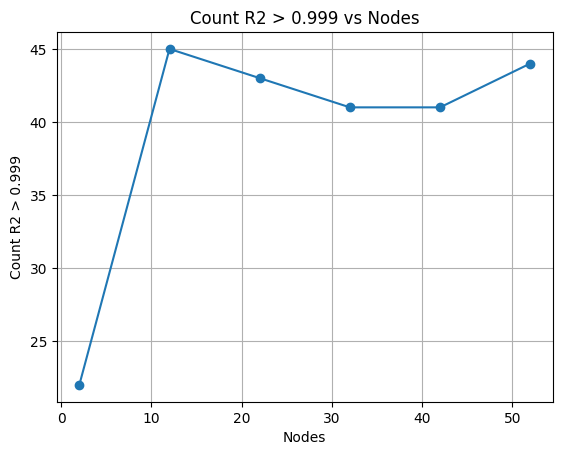

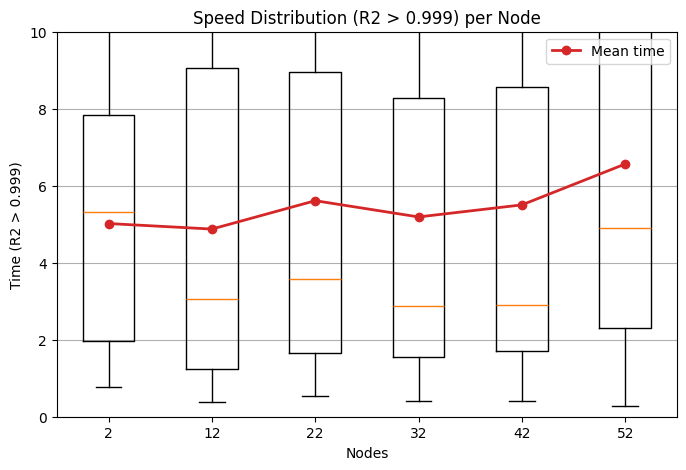

In [14]:
MLPKANresults = pd.read_csv('./parameterTests/MLPKAN_res.csv')
# mean_R2 = MLPKANresults[MLPKANresults['Layers'] == 2].groupby(['Nodes'])['R2 Score'].mean().reset_index()
# plt.plot(mean_R2['Nodes'], mean_R2['R2 Score'], marker='o')
# plt.xlabel('Nodes')
# plt.ylabel('Average R2 Score')
# plt.title('Average R2 Score vs Nodes')
# plt.grid()
# plt.show()
count_R2 = MLPKANresults[(MLPKANresults['R2 Score (Test)'] > 0.999) & (MLPKANresults['Layers'] == 2)].groupby(['Nodes'])['R2 Score (Test)'].count().reset_index()
plt.plot(count_R2['Nodes'], count_R2['R2 Score (Test)'], marker='o')
# plt.ylim(30,80)
plt.xlabel('Nodes')
plt.ylabel('Count R2 > 0.999')
plt.title('Count R2 > 0.999 vs Nodes')
plt.grid()
plt.show()

speed99 = MLPKANresults[(MLPKANresults['R2 Score (Test)'] > 0.999) & (MLPKANresults['Layers'] == 2)]
node_order = sorted(speed99['Nodes'].unique())
speed_by_node = [speed99.loc[speed99['Nodes'] == node, 'time'] for node in node_order]
mean_speed_by_node = [node_times.mean() for node_times in speed_by_node]

plt.figure(figsize=(8, 5))
plt.boxplot(speed_by_node, tick_labels=node_order)
plt.plot(range(1, len(node_order) + 1), mean_speed_by_node, marker='o', color='tab:red', linewidth=2, label='Mean time')
plt.xlabel('Nodes')
plt.ylabel('Time (R2 > 0.999)')
plt.title('Speed Distribution (R2 > 0.999) per Node')
plt.grid(axis='y')
plt.ylim(0, 10)
plt.legend()
plt.show()

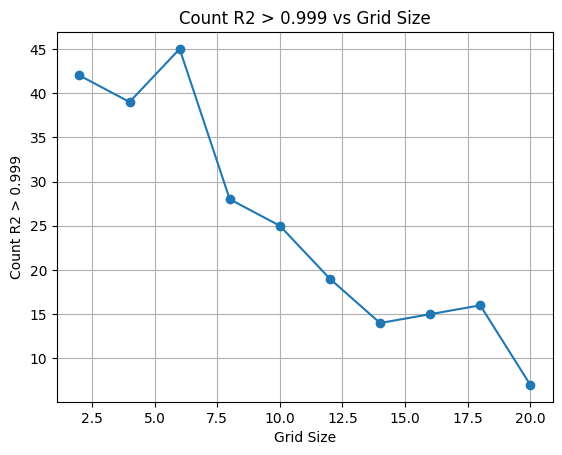

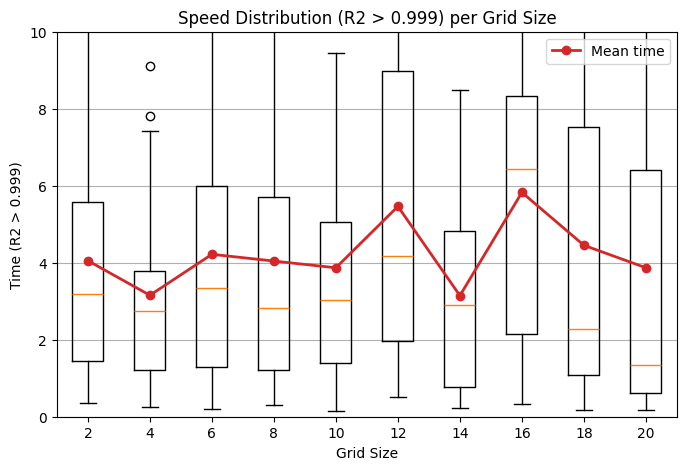

In [9]:
efficientResults = pd.read_csv('./parameterTests/EfficientKAN.csv')
# mean_R2 = efficientResults.groupby(['Grid Size'])['R2 Score'].mean().reset_index()
# plt.plot(mean_R2['Grid Size'], mean_R2['R2 Score'], marker='o')
# plt.xlabel('Grid Size')
# plt.ylabel('Average R2 Score')
# plt.title('Average R2 Score vs Grid Size')
# plt.grid()
# plt.show()
count_R2 = efficientResults[(efficientResults['R2 Score (Test)'] > 0.999)].groupby(['Grid Size'])['R2 Score (Test)'].count().reset_index()
plt.plot(count_R2['Grid Size'], count_R2['R2 Score (Test)'], marker='o')
# plt.ylim(30,80)
plt.xlabel('Grid Size')
plt.ylabel('Count R2 > 0.999')
plt.title('Count R2 > 0.999 vs Grid Size')
plt.grid()
plt.show()

speed99 = efficientResults[(efficientResults['R2 Score (Test)'] > 0.999)]
grid_order = sorted(speed99['Grid Size'].unique())
speed_by_grid = [speed99.loc[speed99['Grid Size'] == grid_size, 'time'] for grid_size in grid_order]
mean_speed_by_grid = [grid_times.mean() for grid_times in speed_by_grid]

plt.figure(figsize=(8, 5))
plt.boxplot(speed_by_grid, tick_labels=grid_order)
plt.plot(range(1, len(grid_order) + 1), mean_speed_by_grid, marker='o', color='tab:red', linewidth=2, label='Mean time')
plt.xlabel('Grid Size')
plt.ylabel('Time (R2 > 0.999)')
plt.title('Speed Distribution (R2 > 0.999) per Grid Size')
plt.grid(axis='y')
plt.ylim(0, 10)
plt.legend()
plt.show()

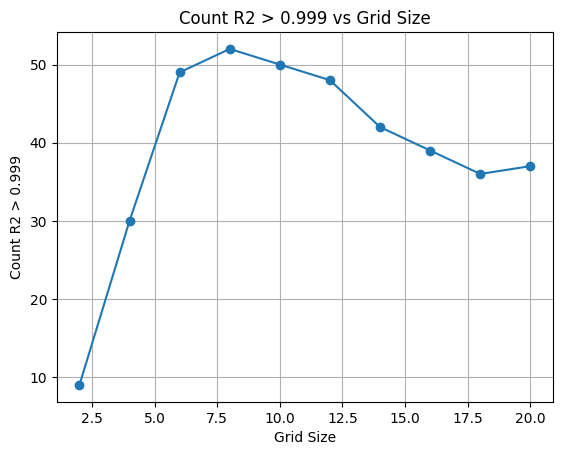

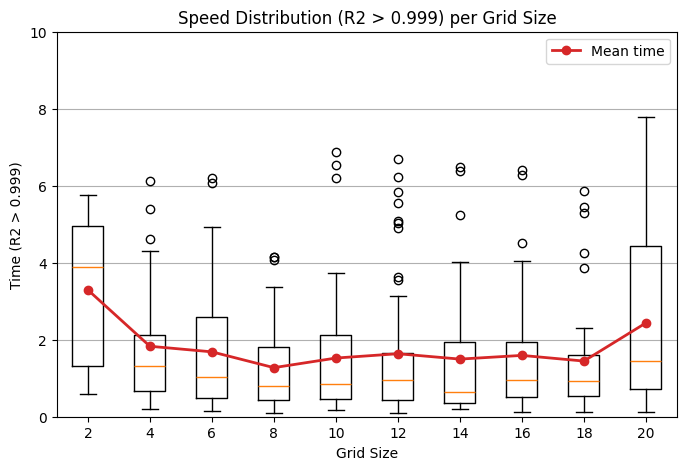

In [10]:
FastKANResults = pd.read_csv('./parameterTests/FastKAN.csv')
# mean_R2 = FastKANResults.groupby(['Grid Size'])['R2 Score'].mean().reset_index()
# plt.plot(mean_R2['Grid Size'], mean_R2['R2 Score'], marker='o')
# plt.xlabel('Grid Size')
# plt.ylabel('Average R2 Score')
# plt.title('Average R2 Score vs Grid Size')
# plt.grid()
# plt.show()
count_R2 = FastKANResults[(FastKANResults['R2 Score (Test)'] > 0.999)].groupby(['Grid Size'])['R2 Score (Test)'].count().reset_index()
plt.plot(count_R2['Grid Size'], count_R2['R2 Score (Test)'], marker='o')
# plt.ylim(30,80)
plt.xlabel('Grid Size')
plt.ylabel('Count R2 > 0.999')
plt.title('Count R2 > 0.999 vs Grid Size')
plt.grid()
plt.show()

speed99 = FastKANResults[(FastKANResults['R2 Score (Test)'] > 0.999)]
grid_order = sorted(speed99['Grid Size'].unique())
speed_by_grid = [speed99.loc[speed99['Grid Size'] == grid_size, 'time'] for grid_size in grid_order]
mean_speed_by_grid = [grid_times.mean() for grid_times in speed_by_grid]

plt.figure(figsize=(8, 5))
plt.boxplot(speed_by_grid, tick_labels=grid_order)
plt.plot(range(1, len(grid_order) + 1), mean_speed_by_grid, marker='o', color='tab:red', linewidth=2, label='Mean time')
plt.xlabel('Grid Size')
plt.ylabel('Time (R2 > 0.999)')
plt.title('Speed Distribution (R2 > 0.999) per Grid Size')
plt.grid(axis='y')
plt.ylim(0, 10)
plt.legend()
plt.show()

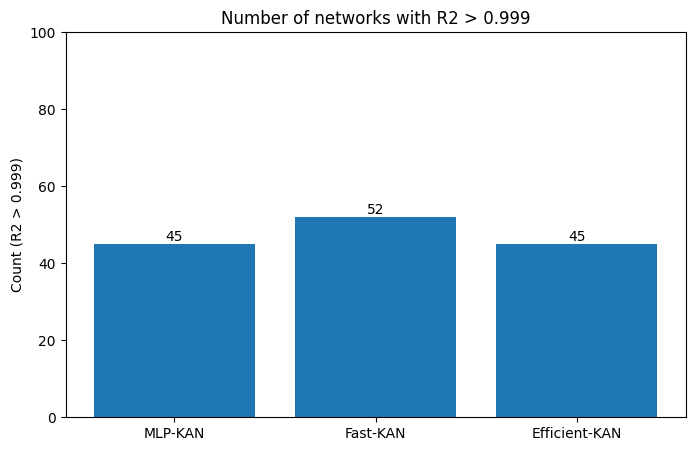

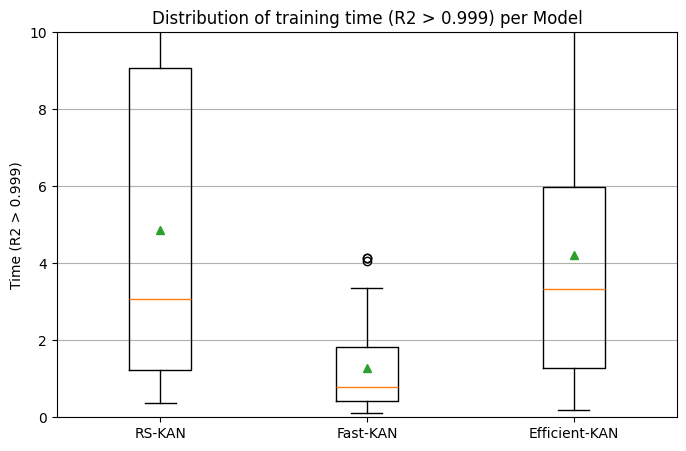

In [11]:
MLPKANperf = MLPKANresults[(MLPKANresults['R2 Score (Test)'] > 0.999) & (MLPKANresults['Layers'] == 2) & (MLPKANresults['Nodes'] == 12)]
fastKANperf = FastKANResults[(FastKANResults['R2 Score (Test)'] > 0.999) & (FastKANResults['Grid Size'] == 8)]
efficientKANperf = efficientResults[(efficientResults['R2 Score (Test)'] > 0.999) & (efficientResults['Grid Size'] == 6)]

labels = ['MLP-KAN', 'Fast-KAN', 'Efficient-KAN']
counts = [len(MLPKANperf), len(fastKANperf), len(efficientKANperf)]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts)

for bar, value in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha='center', va='bottom')

plt.ylim(0,100)
plt.ylabel('Count (R2 > 0.999)')
plt.title('Number of networks with R2 > 0.999')
plt.show()

plt.figure(figsize=(8, 5))
labels = ['RS-KAN', 'Fast-KAN', 'Efficient-KAN']
times = [MLPKANperf['time'], fastKANperf['time'], efficientKANperf['time']]
plt.boxplot(times, tick_labels=labels, showmeans=True)
plt.ylabel('Time (R2 > 0.999)')
plt.title('Distribution of training time (R2 > 0.999) per Model')
plt.grid(axis='y')
plt.ylim(0, 10)
plt.show()



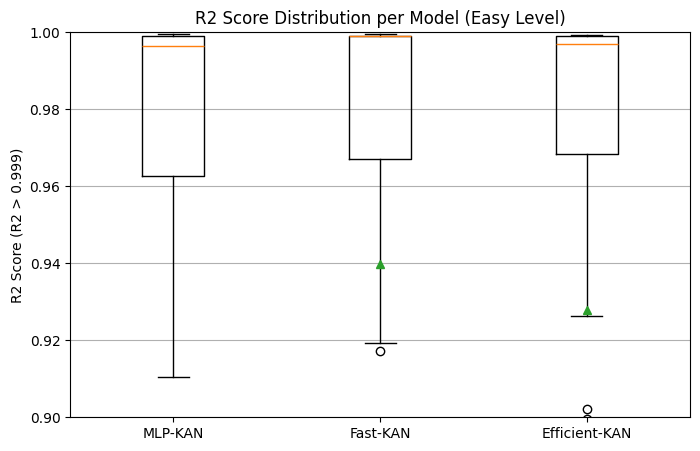

In [12]:
MLPKANacc = MLPKANresults[(MLPKANresults['Layers'] == 2) & (MLPKANresults['Nodes'] == 12) ]
fastKANacc = FastKANResults[(FastKANResults['Grid Size'] == 8) ]
efficientKANacc = efficientResults[(efficientResults['Grid Size'] == 6)]

plt.figure(figsize=(8, 5))
labels = ['MLP-KAN', 'Fast-KAN', 'Efficient-KAN']
r2scores = [MLPKANacc['R2 Score (Test)'], fastKANacc['R2 Score (Test)'], efficientKANacc['R2 Score (Test)']]
plt.boxplot(r2scores, tick_labels=labels, showmeans=True)
plt.ylabel('R2 Score (R2 > 0.999)')
plt.title('R2 Score Distribution per Model (Easy Level)')
plt.grid(axis='y')
plt.ylim(0.9, 1)
plt.show()